In [19]:
import numpy as np

In [20]:


from Nozzle_2D_checkpoint4_2 import Nozzle
import matplotlib.pyplot as plt
import numpy as np
import pickle



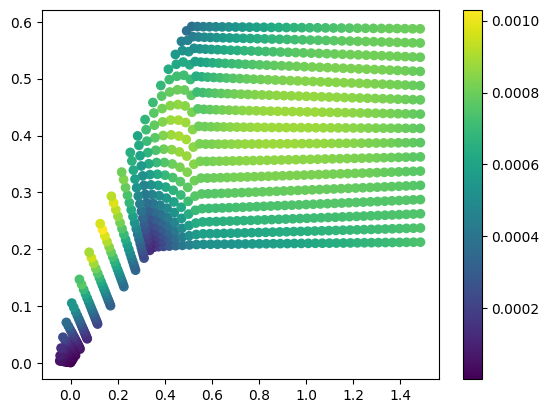

In [21]:
SUPERCOARSE = Nozzle("inputs/RAMP_inputs.nml")
SUPERCOARSE.CFL = .1


self = SUPERCOARSE 
self.CFL = .0000001
self.iter_max = 78000
#self.NI = 20
#self.NJ = 20
# RUN MEDIUM SIMULATION
self.set_arrays()
#self.set_curved_geometry()
#self.load_grid("Meshes/NACA64A006.coarse.53x27.grd")
self.load_grid("Meshes/Inlet.53x17.grd")
self.set_normals()
self.compute_all_areas(visualize=True)

In [22]:
x = np.linspace(self.domain[0], self.domain[1], self.NI)
y = np.linspace(self.domain[0], self.domain[1], self.NJ)
xx_, yy_ = np.meshgrid(y, x)

        

#self.x = xx_**2 +np.cos(yy_)
#self.y =  yy_**2 
#self.A = self.Area()


x = np.linspace(self.domain[0], self.domain[1], self.NI)
y = np.linspace(self.domain[0], self.domain[1], self.NJ)
xx_, yy_ = np.meshgrid(y, x)   # shape (NI, NJ)

# base mapping
#self.x = xx_
#self.y = yy_

# estimate grid spacing in transformed space (roughly uniform scale)
dx = (self.domain[1] - self.domain[0]) / (self.NI - 1)
dy = (self.domain[1] - self.domain[0]) / (self.NJ - 1)

# random perturbations, scaled to a small fraction (say 5%) of spacing
perturb_x = 0.05 * dx * (np.random.rand(*self.x.shape) - 0.5)
perturb_y = 0.05 * dy * (np.random.rand(*self.y.shape) - 0.5)

#self.x += perturb_x
#self.y += perturb_y





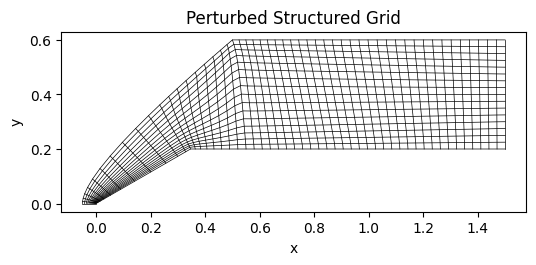

In [23]:
import matplotlib.pyplot as plt

# assume self.x, self.y are [NI,NJ] arrays with perturbed node coordinates

plt.figure(figsize=(6,6))

# draw grid lines in i-direction (rows)
for i in range(self.NI):
    plt.plot(self.x[i,:], self.y[i,:], 'k-', lw=0.5)

# draw grid lines in j-direction (columns)
for j in range(self.NJ):
    plt.plot(self.x[:,j], self.y[:,j], 'k-', lw=0.5)

plt.gca().set_aspect('equal', 'box')
plt.title("Perturbed Structured Grid")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [24]:
#self.load_grid("Meshes/NACA64A006.coarse.53x27.grd")



In [25]:
#self.is_foil=False
self.set_initial_foil_conditions(boundary_mach=.1)

#self.set_inflow_conditions(direction="down",boundary_mach=.075)
#R0 = np.linalg.norm(self.iteration_step()[2])


In [26]:
gamma = 1.4
Mach  = 0.1
p_in  = 1.0
rho_in = 1.0
a_in   = np.sqrt(gamma * p_in / rho_in)   # sound speed
u_in   = Mach * a_in
v_in   = 0.0

# Fill ghost boundary at j=0
self.V[0, 1:-1, 0] = p_in     # pressure
self.V[1, 1:-1, 0] = u_in     # u-velocity
self.V[2, 1:-1, 0] = v_in     # v-velocity
self.V[3, 1:-1, 0] = rho_in   # density


nx_R,ny_R = self.get_normal_directions(direction="left")

rho = self.V[0]
u = self.V[1]
v = self.V[2]
p = self.V[3]
gamma=1.4
E = p / ((gamma - 1.0) * rho) + 0.5 * (u**2 + v**2)
idx =2
F = np.array([rho * u, rho * u**2 + p,rho * u * v,(rho * E + p) * u])
G = np.array([rho*v, rho*u*v, rho*v**2 + p, (rho*E + p)*v])
G = (G[idx,1:-1,:-1] + G[idx,1:-1,:-1])/2
F = (F[idx,1:-1,:-1] + F[idx,1:-1,:-1])/2

((nx_R*F +ny_R*G)[:,0])

array([-1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1.])

In [27]:
# nx_L,ny_L = self.get_normal_directions(direction="left")
# nx_R,ny_R = self.get_normal_directions(direction="right")
# nx_U,ny_U = self.get_normal_directions(direction="up")
# nx_D,ny_D = self.get_normal_directions(direction="down")
# V = self.V





# FL_cell_L = V[:,1:-1,0:-2]
# FL_cell_R = V[:,1:-1,1:-1]
# FR_cell_L = V[:,1:-1,1:-1]
# FR_cell_R = V[:,1:-1,2:]
# FD_cell_L = V[:, 0:-2, 1:-1]   
# FD_cell_R = V[:, 1:-1, 1:-1]  
# FU_cell_L = V[:, 1:-1, 1:-1]   
# FU_cell_R = V[:, 2:  , 1:-1]   

# self.FL[:,:,:-1] = self.vanleer_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,0:-1],ny_L[:,0:-1])
# self.FR[:,:,1:] = self.vanleer_flux_cell(FR_cell_L,FR_cell_R,nx_R[:,1:],ny_R[:,1:])
# self.FD[:, 0:-1, :] = self.vanleer_flux_cell(FD_cell_L, FD_cell_R,nx_D[0:-1, :], ny_D[0:-1, :])
# self.FU[:, 1:, :] = self.vanleer_flux_cell(    FU_cell_L, FU_cell_R,nx_U[1:,:], ny_U[1:, :])

# residual = ((self.FU[:,1:,:]*self.A_top)+(self.FD[:,0:-1,:]*self.A_bottom))+((self.FR[:,:,1:]*self.A_right)+(self.FL[:,:,0:-1]*self.A_left))

In [28]:
nx_L,ny_L = self.get_normal_directions(direction="right")
nx_R,ny_R = self.get_normal_directions(direction="left")
nx_U,ny_U = self.get_normal_directions(direction="up")
nx_D,ny_D = self.get_normal_directions(direction="down")
V = self.V





FL_cell_L = V[:,1:-1,0:-2]
FL_cell_R = V[:,1:-1,1:-1]
FR_cell_L = V[:,1:-1,1:-1]
FR_cell_R = V[:,1:-1,2:]
FD_cell_L = V[:, 0:-2, 1:-1]   
FD_cell_R = V[:, 1:-1, 1:-1]  
FU_cell_L = V[:, 1:-1, 1:-1]   
FU_cell_R = V[:, 2:  , 1:-1]   

self.FL[:,:,:-1] = self.vanleer_flux_cell(FL_cell_L,FL_cell_R,nx_L[:,0:-1],ny_L[:,0:-1])
self.FR[:,:,1:] = self.vanleer_flux_cell(FR_cell_L,FR_cell_R,nx_R[:,1:],ny_R[:,1:])
self.FD[:, 0:-1, :] = self.vanleer_flux_cell(FD_cell_L, FD_cell_R,nx_D[0:-1, :], ny_D[0:-1, :])
self.FU[:, 1:, :] = self.vanleer_flux_cell(    FU_cell_L, FU_cell_R,nx_U[1:,:], ny_U[1:, :])

residual = ((self.FU[:,1:,:]*self.A_top[0])+(self.FD[:,0:-1,:]*self.A_bottom[0]))+((self.FR[:,:,1:]*self.A_right[0])+(self.FL[:,:,:-1]*self.A_left[0]))

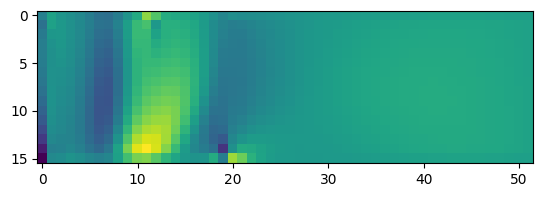

In [29]:
plt.imshow(residual[2])

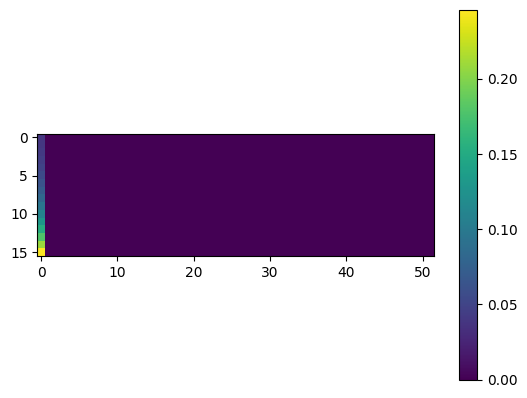

In [30]:
plt.imshow(self.compute_residual_cell()[2])
plt.colorbar()

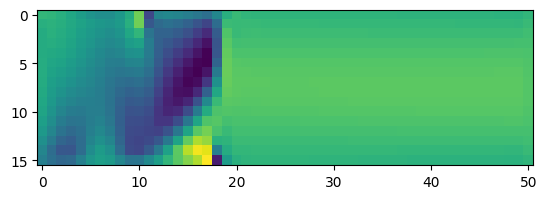

In [31]:
plt.imshow(residual[1,:,1:])

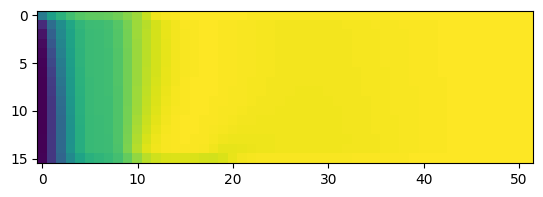

In [32]:
plt.imshow(self.FR[1,:,1:])

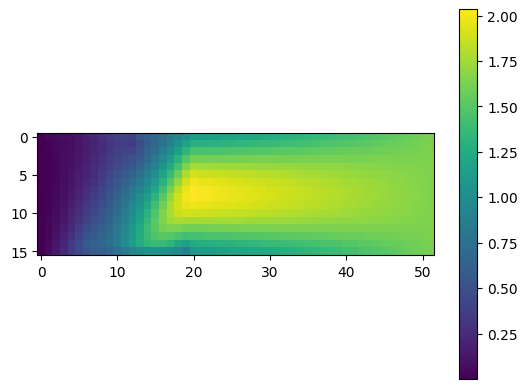

In [33]:

plt.imshow((self.FL[1,:,:-1]*self.A_left[0]))
plt.colorbar()

In [34]:
plt.imshow(((FU[1,1:,:]*self.A_top[0])+(FD[1,0:-1,:]*self.A_bottom[0]))+((FR[1,:,1:]*self.A_right[0])+(FL[1,:,0:-1]*self.A_left[0])))

plt.colorbar()

NameError: name 'FU' is not defined

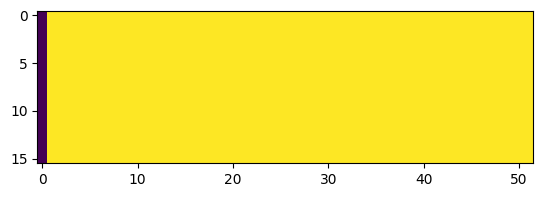

<function matplotlib.pyplot.show(close=None, block=None)>

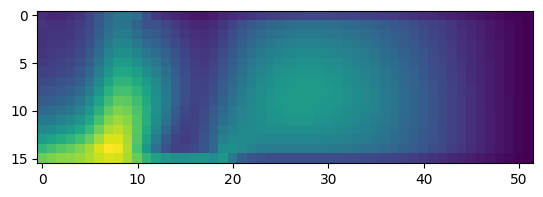

In [ ]:
plt.imshow(FL[2,:,0:-1]+FR[2,:,0:-1])
plt.show()
plt.imshow(FR[2,:,1:]*self.A_right[0])
plt.show

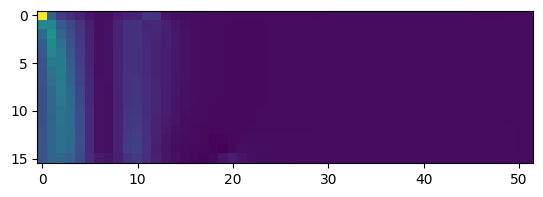

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 

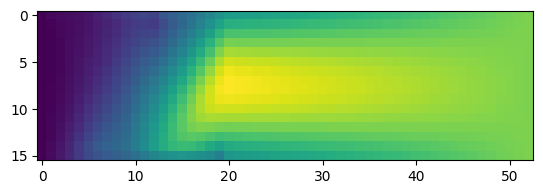

In [ ]:
plt.imshow(FR[1,:,:]*self.A_LR[0])

In [ ]:
plt.imshow(FR[1,:,:]*self.A_LR[0,:,1:])

ValueError: operands could not be broadcast together with shapes (16,53) (16,52) 

In [ ]:
self.A_right-self.A_left

array([[[ 2.83056993e-04, -3.97455104e-05,  1.85635249e-04, ...,
          2.80175008e-04,  2.94373151e-04,  2.13707253e-04],
        [ 3.88402954e-04, -3.69043990e-05,  1.44554818e-04, ...,
          1.97374607e-04,  2.03106627e-04,  1.25294515e-04],
        [ 2.16678286e-04,  1.27589191e-04,  1.58787524e-04, ...,
          9.59254813e-05,  9.46822007e-05,  5.71702291e-05],
        ...,
        [ 1.63250455e-04,  4.40278361e-04,  7.49826574e-04, ...,
          8.79051189e-05,  8.70591569e-05,  5.17307579e-05],
        [ 2.92037015e-04,  6.00809468e-04,  8.80641716e-04, ...,
          1.96843521e-04,  2.03335463e-04,  1.24439164e-04],
        [ 3.65697489e-04,  4.82209740e-04,  6.79848369e-04, ...,
          2.90500156e-04,  3.03562107e-04,  2.20625012e-04]],

       [[ 2.83056993e-04, -3.97455104e-05,  1.85635249e-04, ...,
          2.80175008e-04,  2.94373151e-04,  2.13707253e-04],
        [ 3.88402954e-04, -3.69043990e-05,  1.44554818e-04, ...,
          1.97374607e-04,  2.03106627e

In [ ]:
plt.show()
plt.imshow((FL[1,:,:]*self.A_left[0])[:,1:])

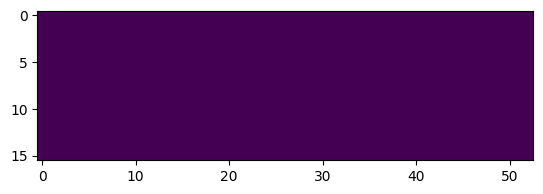

ValueError: operands could not be broadcast together with shapes (16,53) (16,52) 

In [ ]:
nx_L,ny_L = self.get_normal_directions(direction="left")
nx_R,ny_R = self.get_normal_directions(direction="right")
nx_U,ny_U = self.get_normal_directions(direction="up")
nx_D,ny_D = self.get_normal_directions(direction="down")
V = self.V
FL_cell_L = V[:,1:-1,0:-1]
FL_cell_R = V[:,1:-1,1:]
FL = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_L,ny_L)+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_L,ny_L)

#FL_cell_L = V[:,1:-1,1:-1]
#FL_cell_R = V[:,1:-1,2:]
FR = self.f_convective_cell(FL_cell_L,FL_cell_R,nx_R,ny_R)+self.f_pressure_flux_cell(FL_cell_L,FL_cell_R,nx_R,ny_R)
plt.imshow((FR[1,:,:]*self.A_LR[0])+(FL[1,:,:]*self.A_LR[0]))
plt.show()
plt.imshow((FL[1,:,:]*self.A_left[0])[:,1:])